Phase 1: Perceptron Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

And Gate Dataset


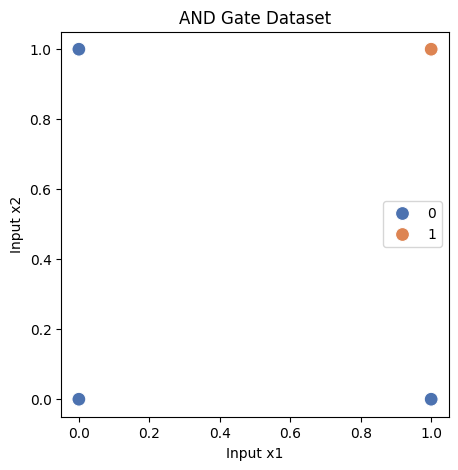

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 0, 0, 1])

plt.figure(figsize=(5,5))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y, palette="deep", s=100)
plt.title("AND Gate Dataset")
plt.xlabel("Input x1")
plt.ylabel("Input x2")
plt.show()


Perceptron class

In [4]:
import numpy as np

class Perceptron:
    def __init__(self, input_size, lr=0.1, epochs=10):
        self.weights = np.zeros(input_size + 1)
        self.lr = lr
        self.epochs = epochs

    def activation(self, x):
        return 1 if x >= 0 else 0

    def predict(self, x):
        z = np.dot(x, self.weights[1:]) + self.weights[0]
        return self.activation(z)

    def fit(self, X, y):
        for _ in range(self.epochs):
            for xi, target in zip(X, y):
                prediction = self.predict(xi)
                error = target - prediction
                self.weights[1:] += self.lr * error * xi
                self.weights[0] += self.lr * error


Train Perceptron on AND Gate


In [5]:
perceptron = Perceptron(input_size=2, lr=0.1, epochs=10)
perceptron.fit(X,y)
predictions = [perceptron.predict(xi) for xi in X]
print("Predictions:", predictions)
print("Actual:", y.tolist())
print("Final Weights:", perceptron.weights)

Predictions: [0, 0, 0, 1]
Actual: [0, 0, 0, 1]
Final Weights: [-0.2  0.2  0.1]


Decision Boundary Visulization


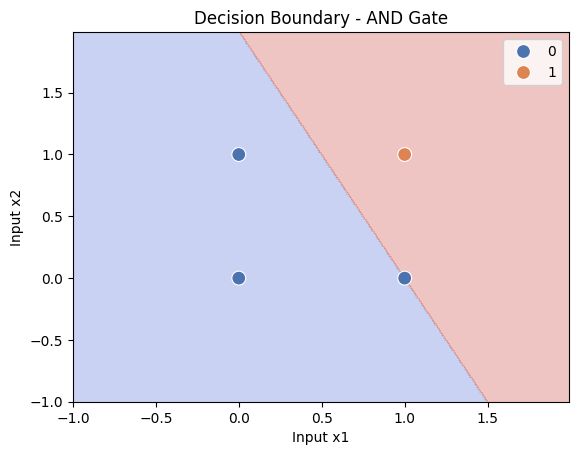

In [6]:
x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

grid = np.c_[xx.ravel(), yy.ravel()]
Z = np.array([perceptron.predict(point) for point in grid])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y, palette="deep", s=100)
plt.title("Decision Boundary - AND Gate")
plt.xlabel("Input x1")
plt.ylabel("Input x2")
plt.show()


Loss Curve

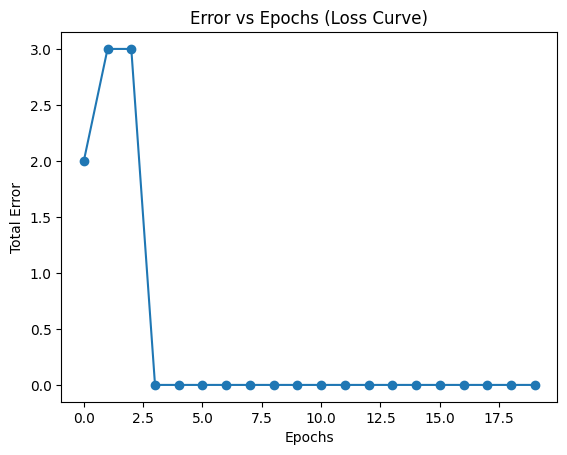

In [7]:
errors = []

perceptron = Perceptron(input_size=2, lr=0.1, epochs=20)

for _ in range(perceptron.epochs):
    total_error = 0
    for xi, target in zip(X, y):
        prediction = perceptron.predict(xi)
        error = target - prediction
        total_error += abs(error)
        perceptron.weights[1:] += perceptron.lr * error * xi
        perceptron.weights[0] += perceptron.lr * error
    errors.append(total_error)

plt.plot(range(perceptron.epochs), errors, marker='o')
plt.title("Error vs Epochs (Loss Curve)")
plt.xlabel("Epochs")
plt.ylabel("Total Error")
plt.show()


XOR dataset And Perceptron limitation

Predictions: [1, 1, 0, 0]
Actual: [0, 1, 1, 0]


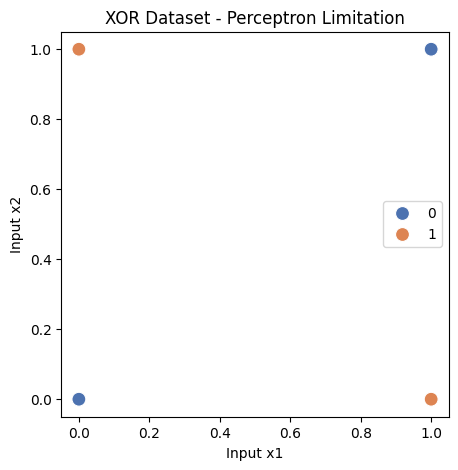

In [8]:
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_xor = np.array([0, 1, 1, 0])

perceptron_xor = Perceptron(input_size=2, lr=0.1, epochs=20)
perceptron_xor.fit(X_xor, y_xor)

predictions_xor = [perceptron_xor.predict(xi) for xi in X_xor]
print("Predictions:", predictions_xor)
print("Actual:", y_xor.tolist())

plt.figure(figsize=(5,5))
sns.scatterplot(x=X_xor[:,0], y=X_xor[:,1], hue=y_xor, palette="deep", s=100)
plt.title("XOR Dataset - Perceptron Limitation")
plt.xlabel("Input x1")
plt.ylabel("Input x2")
plt.show()


Phase 1: Perceptron Foundations

- The perceptron is a linear classifier.
- It calculates a weighted sum of inputs plus a bias.
- The activation function (step function) decides the output (0 or 1).
- It can solve linear problems like AND and OR gates.
- During training, weights are updated and error gradually decreases (loss curve).
- Decision boundary visualization shows how the model separates classes.
- The perceptron fails on non-linear problems like XOR.
- This limitation led to the development of Multi-Layer Perceptrons (Phase 2).
